In [1]:
import numpy as np
import rasterio
from rasterio.transform import from_bounds
from pysheds.grid import Grid
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

In [2]:
from scipy.sparse import lil_matrix, csr_matrix

In [3]:
dem_path = '/Users/nestorw/Geodyne/gdnn/Graftn/MicaDEM_13Aug25_1m.tif'
mask_path = '/Users/nestorw/Geodyne/gdnn/Graftn/MicaDEM_13Aug25_1mvalidmask.tif'

In [4]:
# load DEM with metadata

with rasterio.open(dem_path) as src:
    dem_array = src.read(1).astype(np.float32)
    dem_transform = src.transform
    dem_crs = src.crs
    dem_nodata = src.nodata
    dem_shape = src.shape
    dem_bounds = src.bounds

print(f"dem shape: {dem_shape}")
print(f"nodata val: {dem_nodata}")
print(f"value range: {dem_array[dem_array != dem_nodata].min():.2f} to {dem_array[dem_array != dem_nodata].max():.2f}")

dem shape: (2530, 2654)
nodata val: -32767.0
value range: 807.80 to 987.26


In [5]:
# load valid mask
with rasterio.open(mask_path) as src:
    valid_mask = src.read(1).astype(bool)

print(f"valid pixels: {valid_mask.sum()} of {valid_mask.size} ({100*valid_mask.sum()/valid_mask.size:.1f}%)")

valid pixels: 2112178 of 6714620 (31.5%)


In [6]:
# apply mask -- set nodata outside valid footprint
dem_array[~valid_mask] = dem_nodata

In [9]:
def add_scalebar(ax, pixel_size_m=1.0, length_m=500, color='white'):
    """add simple scale bar to a matplotlib axis."""
    # get axis dimension in pixels
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    ax_width = xlim[1] - xlim[0]
    ax_height = ylim[0] - ylim[1] # inverted for img coords

    # scalebar length in pixels
    bar_pixels = length_m / pixel_size_m

    # position: bottom left, 5% margin
    x_start = xlim[0] + 0.05*ax_width
    y_pos = ylim[0] - 0.05*ax_height
    bar_height = 0.015 * ax_height

    # draw bar
    ax.add_patch(Rectangle((x_start, y_pos), bar_pixels, bar_height,
                            color=color, zorder=5))

     # Label
    ax.text(x_start + bar_pixels / 2, y_pos - 0.025 * ax_height,
            f'{length_m}m', color=color, fontsize=9,
            ha='center', va='top', zorder=5)


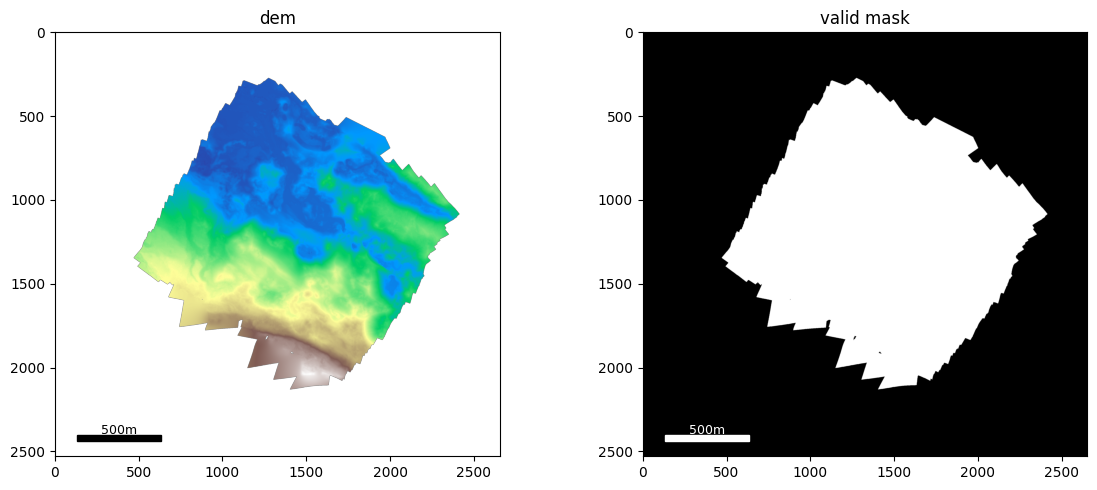

In [10]:
# visual check
fig, axes = plt. subplots(1,2, figsize=(12, 5))
dem_display = np.where(dem_array == dem_nodata, np.nan, dem_array)
axes[0].imshow(dem_display, cmap='terrain')
axes[0].set_title('dem')
add_scalebar(axes[0], pixel_size_m = 1.0, length_m=500, color='black')

axes[1].imshow(valid_mask, cmap='gray')
axes[1].set_title('valid mask')
add_scalebar(axes[1], pixel_size_m = 1.0, length_m=500, color='white')

plt.tight_layout()
plt.show()

In [11]:
## step 2 -- hydrological conditioning with pysheds

# initialize pysheds Grid from dem file
grid = Grid.from_raster(dem_path)
dem = grid.read_raster(dem_path)

print(f"grid shape: {grid.shape}")
print(f"dem dtype: {dem.dtype}")

grid shape: (2530, 2654)
dem dtype: float32


In [12]:
# fill pits -----
pits_filled = grid.fill_pits(dem)
print("pits filled")

# fill depressions ---
flooded = grid.fill_depressions(pits_filled)
print("depressions filled")

# resolve flats
inflated = grid.resolve_flats(flooded)
print("flats resolved")

print("hydrological conditioning complete")

pits filled
depressions filled
flats resolved
hydrological conditioning complete


In [13]:
### step 3 --- flow accumulations


# d8 dirmap: (NE, N, NW, W, SW, S, SE, E)
dirmap = (64, 128, 1, 2, 4, 8, 16, 32)

# flow directions using MFD (Multiple Flow Direction)
fdir = grid.flowdir(inflated, dirmap=dirmap)
print(f"flow direction computed, unique values {np.unique(fdir)}")

# flow accumulations
acc = grid.accumulation(fdir, dirmap=dirmap)
print(f"flow accumulation range: {acc.min():.0f} to {acc.max():.0f}")

flow direction computed, unique values [ -2  -1   0   1   2   4   8  16  32  64 128]
flow accumulation range: 0 to 767111


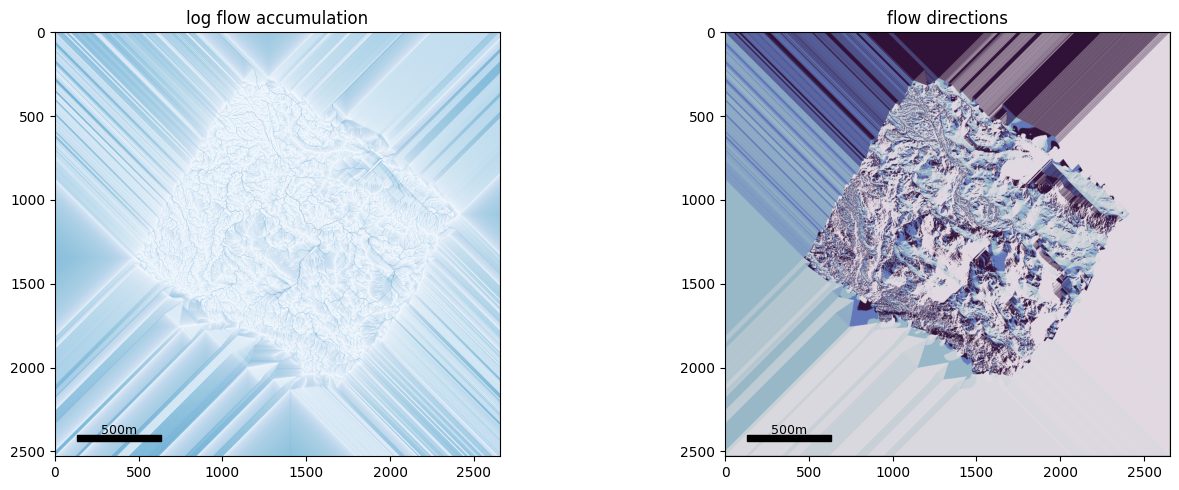

In [14]:
# visualize
fig, axes = plt.subplots(1, 2, figsize=(14,5))

acc_display = np.where(np.array(acc) <= 0, np.nan, np.log1p(np.array(acc)))
axes[0].imshow(acc_display, cmap='Blues')
axes[0].set_title('log flow accumulation')
add_scalebar(axes[0], pixel_size_m = 1.0, length_m=500, color='black')

fdir_display = np.where(np.array(fdir) <= 0, np.nan, np.array(fdir))
axes[1].imshow(fdir_display, cmap='twilight')
axes[1].set_title('flow directions')
add_scalebar(axes[1], pixel_size_m = 1.0, length_m=500, color='black')

plt.savefig("fig_micanwell_accdirs.png")
plt.tight_layout()
plt.show()

In [15]:
### step 4 ---- build spares flow direction matrix and grid adjacency (simple) matrix

In [16]:
## map valid pixels to node indices
# valid mask is (2530, 2654) boolean array
# we need a mapping: (row, col) -> node_index for valid pixels only

fdir_array = np.array(fdir)
valid = valid_mask.copy()

# create node index map -- -1 means invalid
node_index = np.full(valid.shape, -1, dtype=np.int32)
valid_coords = np.argwhere(valid) # shape (n_valid, 2) -- (row, col)
n_nodes = len(valid_coords)
node_index[valid_coords[:, 0], valid_coords[:,1]] = np.arange(n_nodes)

print(f"number of nodes: {n_nodes}")


number of nodes: 2112178


In [17]:
# --- D8 direction offsets ---
# dirmap = (64, 128, 1, 2, 4, 8, 16, 32)
# correspond to (NE, N, NW, W, SW, S, SE, E)
d8_offsets = {
    64:  (-1,1),  #NE
    128: (-1,0),  #N
    1:   (-1,-1), #NW
    2:   ( 0,-1), #W
    4:   ( 1,-1), #SW
    8:   ( 1, 0), #S
    16:  ( 1, 1), #SE
    32:  ( 0, 1)  #E
}

In [20]:
### flow direction edge list ###

In [21]:
# all valid pixel coords #
rows = valid_coords[:,0]
cols = valid_coords[:,1]

In [23]:
# d8 offsets as arrays #
d8_dirs   = np.array([64,  128,  1,  2,  4, 8,  16, 32])
d8_dr     = np.array([-1,  -1,  -1,  0,  1, 1,  1,   0])
d8_dc     = np.array([ 1,   0,  -1, -1, -1, 0,  1,   1])
d8_dist   = np.sqrt(d8_dr**2 + d8_dc**2).astype(np.float32)

In [26]:
flow_src_list = []
flow_dst_list = []
flow_wgt_list = []

grid_src_list = []
grid_dst_list = []

for k in range(8): # each possible neighbor direction
    dr = d8_dr[k]
    dc = d8_dc[k]
    dist = d8_dist[k]

    # neighbor coordinates for all valid nodes
    nr = rows + dr
    nc = cols + dc

    # bounds check
    in_bounds = (nr >= 0) & (nr < valid.shape[0]) & \
                (nc >= 0) & (nc < valid.shape[1])

    # valid neighbor check
    nr_safe = np.where(in_bounds, nr, 0)
    nc_safe = np.where(in_bounds, nc, 0)
    neighbor_idx = node_index[nr_safe, nc_safe]
    has_valid_neighbor = in_bounds & (neighbor_idx >= 0)

    # source node indices
    src_idx = np.arange(n_nodes)

    # grid adjacency -- all valid neighbors
    mask = has_valid_neighbor
    grid_src_list.append(src_idx[mask])
    grid_dst_list.append(neighbor_idx[mask])

    # flow direction -- only where fdir matches this direction
    fdir_match = fdir_array[rows, cols] == d8_dirs[k]
    flow_mask = has_valid_neighbor & fdir_match

    if flow_mask.any():
        # slope weight
        elev_src = dem_array[rows[flow_mask], cols[flow_mask]]
        elev_dst = dem_array[nr_safe[flow_mask], nc_safe[flow_mask]]
        slope = (elev_src - elev_dst) / dist
        slope = np.maximum(slope, 0.0)

        flow_src_list.append(src_idx[flow_mask])
        flow_dst_list.append(neighbor_idx[flow_mask])
        flow_wgt_list.append(slope)

## concatenate ---
flow_src = np.concatenate(flow_src_list).astype(np.int64)
flow_dst = np.concatenate(flow_dst_list).astype(np.int64)
flow_wgt = np.concatenate(flow_wgt_list).astype(np.float32)

grid_src = np.concatenate(grid_src_list).astype(np.int64)
grid_dst = np.concatenate(grid_dst_list).astype(np.int64)
grid_wgt = np.ones(len(grid_src), dtype=np.float32)

"""
### use this only for true MFD ###
# normalize flow weights so each source node sums to 1
from numpy import bincount
weight_sum = bincount(flow_src, weights=flow_wgt, minlength=n_nodes)
weight_sum = np.maximum(weight_sum, 1e-10)
flow_wgt = flow_wgt / weight_sum[flow_src]
"""
print(f"flow edges: {len(flow_src)}")
print(f"grid edges: {len(grid_src)}")

flow edges: 2109312
grid edges: 16873760


In [27]:
# ---- save ----
np.save('flow_src.npy', flow_src)
np.save('flow_dst.npy', flow_dst)
np.save('flow_wgt.npy', flow_wgt)
np.save('grid_src.npy', grid_src)
np.save('grid_dst.npy', grid_dst)
np.save('valid_coords.npy', valid_coords)
np.save('node_index.npy', node_index)

print('saved')

saved


In [28]:
### node features ###

In [31]:
from scipy.ndimage import sobel, generic_laplace, uniform_filter

In [33]:
# elevation, mask nodata
elev = dem_array.copy().astype(np.float32)
elev[~valid_mask] = np.nan

In [40]:
# slope -- load from gdal preprocessing
with rasterio.open('MicaSlope_13Aug25_1m.tif') as src:
    slope_array = src.read(1).astype(np.float32)
    slope_nodata = src.nodata
    
slope_array[~valid_mask] = np.nan

In [41]:
# aspect ---- load from gdal preprocessing
with rasterio.open('MicaAspect_13Aug25_1m.tif') as src:
    aspect_array = src.read(1).astype(np.float32)
    aspect_nodata = src.nodata

aspect_array[~valid_mask] = np.nan

# convert to sin/cos components
# accounts for  0 ~ 360 identical but numerical difference
aspect_rad = np.radians(aspect_array)
aspect_sin = np.sin(aspect_rad)
aspect_cos = np.cos(aspect_rad)

In [48]:
# curvature 

# --- laplacian approximation ---
# laplacian = center - mean of neighbors
elev_clean = np.nan_to_num(elev)
elev_smooth = uniform_filter(elev_clean, size=3)
curvature = elev_clean - elev_smooth
curvature[~valid_mask] = np.nan

print(f"curvature range: {np.nanmin(curvature):.4f} to {np.nanmax(curvature):.4f}")

# remove boundary artifacts
# percentile clipping rather than fixed values
p1 = np.nanpercentile(curvature, 1)
p99 = np.nanpercentile(curvature, 99)
curvature_clipped = np.clip(curvature, p1, p99)
curvature_clipped[~valid_mask] = np.nan

print(f"curvature clipped range: {np.nanmin(curvature_clipped):.4f} to {np.nanmax(curvature_clipped):.4f}")

curvature range: -12.8752 to 743.8455
curvature clipped range: -0.1816 to 0.2643


In [43]:
# flow accumulation -- --
acc_array = np.array(acc).astype(np.float32)
acc_array[~valid_mask] = np.nan
# log transform -- accumulation spans orders of magnitude
log_acc = np.log1p(acc_array)

In [50]:
print("Topographic features computed")
print(f"Slope range: {np.nanmin(slope_array):.3f} to {np.nanmax(slope_array):.3f}")
print(f"Aspect range: {np.nanmin(aspect_rad):.1f} to {np.nanmax(aspect_rad):.1f}")
print(f"Aspect sin range: {np.nanmin(aspect_sin):.3f} to {np.nanmax(aspect_sin):.3f}")
print(f"Aspect cos range: {np.nanmin(aspect_cos):.3f} to {np.nanmax(aspect_cos):.3f}")
print(f"Curvature clipped range: {np.nanmin(curvature_clipped):.4f} to {np.nanmax(curvature_clipped):.4f}")
print(f"Log accumulation range: {np.nanmin(log_acc):.2f} to {np.nanmax(log_acc):.2f}")

Topographic features computed
Slope range: 0.003 to 83.259
Aspect range: 0.0 to 6.3
Aspect sin range: -1.000 to 1.000
Aspect cos range: -1.000 to 1.000
Curvature clipped range: -0.1816 to 0.2643
Log accumulation range: 0.69 to 13.55


In [57]:
## route difference DEM through flow structure
# landscape memory feature

# load clipped diffDEM
difdem_path = 'CanDiff2000Aug25_Mica13Aug251mClipped.tif'

with rasterio.open(difdem_path) as src:
    diff_array = src.read(1).astype(np.float32)
    diff_nodata = src.nodata
    print(f"diff shape: {diff_array.shape}")
    print(f"diff nodata: {diff_nodata}")

# mask nodata
if diff_nodata is not None:
    diff_array[diff_array == diff_nodata] = np.nan
diff_array[~valid_mask] = np.nan

diff shape: (2530, 2654)
diff nodata: -32767.0


In [58]:
# apply Feynman's sign rule
diff_array = - diff_array

In [59]:
print(f"diff range: {np.nanmin(diff_array):.3f} to {np.nanmax(diff_array):.3f}")
print(f"diff mean: {np.nanmean(diff_array):.3f}")
print(f"negative pixels (loss): {(diff_array <0).sum()}")
print(f"positive pixels (gain): {(diff_array >0).sum()}")

diff range: -88.073 to 19.852
diff mean: -16.619
negative pixels (loss): 2026148
positive pixels (gain): 76683


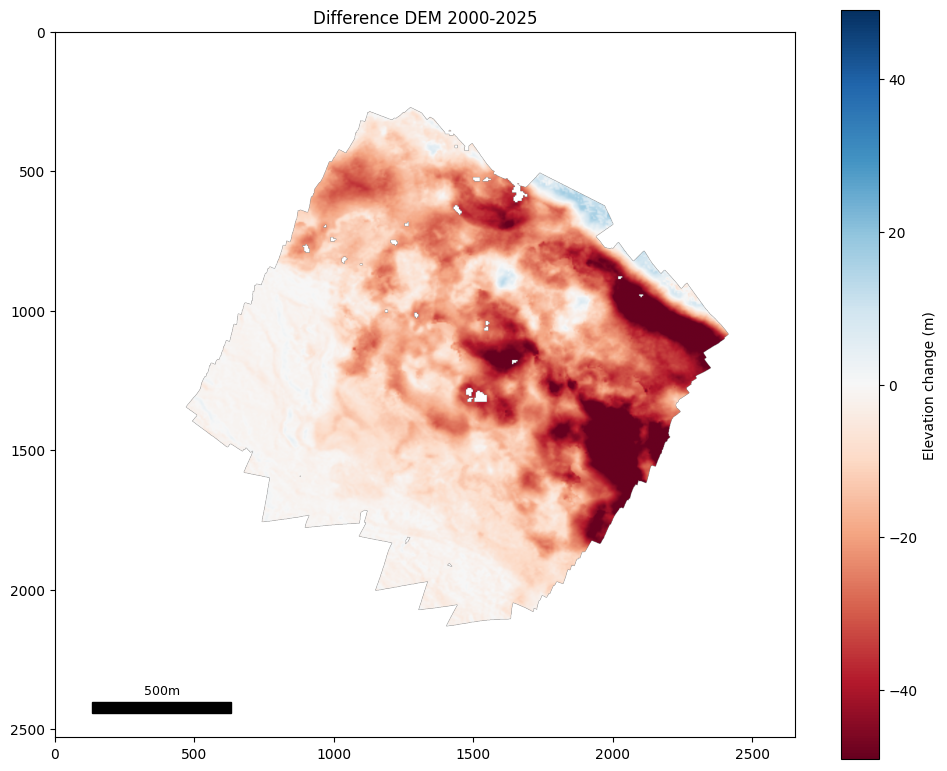

In [61]:
fig, ax = plt.subplots(figsize=(10, 8))
diff_display = diff_array.copy()
vmax = np.nanpercentile(np.abs(diff_display), 95)
im = ax.imshow(diff_display, cmap='RdBu', vmin=-vmax, vmax=vmax)
plt.colorbar(im, ax=ax, label='Elevation change (m)')
ax.set_title('Difference DEM 2000-2025')
add_scalebar(ax, pixel_size_m=1.0, length_m=500, color='black')
# plt.savefig('fig_diffTerminus.png')
plt.tight_layout()
plt.show()

In [ ]:
#### implement flow iterative routing #####

In [62]:
# build sparse flow direction matrix M #
# M[i,j] = weight of flow from node i to node j
M = csr_matrix(
    (flow_wgt, (flow_src, flow_dst)),
    shape=(n_nodes, n_nodes),
    dtype = np.float32
)
print(f"M shape: {M.shape}")
print(f"M nonzero entries: {M.nnz}")

M shape: (2112178, 2112178)
M nonzero entries: 2109312


In [63]:
## initial condition w(0) = difference values at valid nodes
diff_valid = diff_array[valid_coords[:,0],
                        valid_coords[:,1]]

###### ASSUMPTION????? ########
# replace remaining nans with 0 -- no signal at the nodes
diff_valid = np.nan_to_num(diff_valid, nan=0.0).astype(np.float32)

print(f"diff signal range at nodes: {diff_valid.min():.3f} to {diff_valid.max():.3f}")
print(f"non-zero signal nodes: {(diff_valid !=0).sum()}")

diff signal range at nodes: -88.073 to 19.852
non-zero signal nodes: 2102831


In [ ]:
# normalize M to row stochastic ---
# each row should sum to 1
row_sums = np.array(M.sum(axis=1)).flatten()
row_sums = np.maximum(row_sums, 1e-10) # avoid div by zero

# create diagonal matrix of inverse row sums
D_inv = np.diag(1.0 / row_sums)
M_normalized = D_inv.dot(M)

# verify normalization
test_sums = np.array(M_normalized.sum(axis=1)).flatten()
print(f"row sum range after normalization: {test_sums.min():.4f} to {test_sums.max():.4f}")
# should be 0 to 1 --- sink nodes sum to 0, the rest to 1.

In [65]:
### iterative routing:
# a = w(0) + M^T w(0) + (M^T)^2 w(0) + ...
# stop when update is negligible

MT = M.T # transpose for routing

w = diff_valid.copy()
accumulated = diff_valid.copy()

print("routing signal through flow network...")
max_iter = 10000
tol = 1e-4

for k in range(max_iter):
    w_new = MT.dot(w)
    accumulated += w_new

    # check convergence -- max absolute change
    delta = np.abs(w_new).max()

    if k % 100 == 0:
        print(f" Iteration {k}, max signal: {delta:.6f}")

    if delta < tol:
        print(f"converged at iteration {k}")
        break

    w - w_new

print(f"routed diff range: {accumulated.min():.3f} to {accumulated.max():.3f}")
print(f"routed diff mean: {accumulated.mean():.3f}")

routing signal through flow network...
 Iteration 0, max signal: 1013.934326
 Iteration 100, max signal: 1013.934326
 Iteration 200, max signal: 1013.934326
 Iteration 300, max signal: 1013.934326
 Iteration 400, max signal: 1013.934326
 Iteration 500, max signal: 1013.934326
 Iteration 600, max signal: 1013.934326
 Iteration 700, max signal: 1013.934326
 Iteration 800, max signal: 1013.934326
 Iteration 900, max signal: 1013.934326
 Iteration 1000, max signal: 1013.934326
 Iteration 1100, max signal: 1013.934326
 Iteration 1200, max signal: 1013.934326
 Iteration 1300, max signal: 1013.934326
 Iteration 1400, max signal: 1013.934326
 Iteration 1500, max signal: 1013.934326
 Iteration 1600, max signal: 1013.934326
 Iteration 1700, max signal: 1013.934326
 Iteration 1800, max signal: 1013.934326
 Iteration 1900, max signal: 1013.934326
 Iteration 2000, max signal: 1013.934326
 Iteration 2100, max signal: 1013.934326
 Iteration 2200, max signal: 1013.934326
 Iteration 2300, max signal: 1

# slope -- via sobel gradients
# sobel gradient in x and y directions
dz_dx = sobel(np.nan_to_num(elev), axis=1) / 8.0
dz_dy = sobel(np.nan_to_num(elev), axis=0) / 8.0
slope = np.sqrt(dz_dx**2 + dz_dy**2)
slope[~valid_mask] = np.nan

# aspect ----
aspect = np.arctan2(dz_dy, -dz_dx)
aspect_deg = np.degrees(aspect) % 360
aspect_deg[~valid_mask] = np.nan